In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

In [2]:
base = Path(r"C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis")

input_path_rf = base / "data" / "rf_weekly_summary.parquet"
input_path_xgb = base / "data" / "xgb_weekly_summary.parquet"
input_path_EVs = base / "data" / "EVs_evolution_2024.csv"
save_path_rf = base / "results" 
save_path_xgb = base / "results" 
save_path_EVs = base / "results"


df_rf  = pl.scan_parquet(input_path_rf).collect(engine = "streaming")
df_xgb = pl.scan_parquet(input_path_xgb).collect(engine = "streaming")
df_EVs = pl.read_csv(input_path_EVs, separator = ",", has_header = True, try_parse_dates = True)

In [3]:
# Change this value each time you want another charger probability threshold.
# Available thresholds: 0.50, 0.70, 0.80, 0.90, 0.95, 0.99
PROBABILITY_THRESHOLD = 0.90

WEEK_COL = "week_id"
EV_MONTH_COL = "month_start"
EV_COUNT_COL = "n_active_EVs_DMRB"
AVAILABLE_THRESHOLDS = [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]


def threshold_to_column(threshold: float) -> str:
    threshold_pct = int(round(threshold * 100))
    col = f"n_pred_EV_{threshold_pct}"

    if threshold_pct not in {int(t * 100) for t in AVAILABLE_THRESHOLDS}:
        raise ValueError(
            f"Unsupported threshold {threshold}. Use one of: {AVAILABLE_THRESHOLDS}"
        )

    return col


def monthly_charger_average(
    df: pl.DataFrame,
    threshold: float,
    model_name: str,
) -> pl.DataFrame:
    pred_col = threshold_to_column(threshold)

    return (
        df
        .with_columns(
            (
                pl.date(2024, 1, 1)
                + pl.duration(days=(pl.col(WEEK_COL) - 1) * 7)
            ).alias("week_start")
        )
        .with_columns(
            pl.col("week_start").dt.truncate("1mo").alias("month_start")
        )
        .group_by("month_start")
        .agg(
            pl.col(pred_col).mean().alias(f"{model_name}_chargers")
        )
        .sort("month_start")
    )


def build_monthly_ev_charger_plot_data(
    df_ev: pl.DataFrame,
    df_rf: pl.DataFrame,
    df_xgb: pl.DataFrame,
    threshold: float,
) -> pl.DataFrame:
    ev_monthly = (
        df_ev
        .select(
            pl.col(EV_MONTH_COL).cast(pl.Date).alias("month_start"),
            pl.col(EV_COUNT_COL).alias("DMRB_active_EVs"),
        )
        .filter(pl.col("month_start").dt.year() == 2024)
        .sort("month_start")
    )

    rf_monthly = monthly_charger_average(df_rf, threshold, "RF")
    xgb_monthly = monthly_charger_average(df_xgb, threshold, "XGBoost")

    return (
        ev_monthly
        .join(rf_monthly, on="month_start", how="left")
        .join(xgb_monthly, on="month_start", how="left")
        .sort("month_start")
    )


def plot_monthly_ev_and_chargers(
    df_ev: pl.DataFrame,
    df_rf: pl.DataFrame,
    df_xgb: pl.DataFrame,
    threshold: float = PROBABILITY_THRESHOLD,
    save_path: str | Path | None = None,
    dpi: int = 200,
) -> plt.Figure:
    plot_df = build_monthly_ev_charger_plot_data(
        df_ev=df_ev,
        df_rf=df_rf,
        df_xgb=df_xgb,
        threshold=threshold,
    )

    months = plot_df["month_start"].to_list()
    x = np.arange(len(months))
    month_labels = [m.strftime("%b") for m in months]

    fig, ax = plt.subplots(figsize=(12, 5.5))

    series = [
        ("DMRB active EVs", "DMRB_active_EVs", "#1f2937", "-", 2.3),
        (
            f"RF chargers, P>={int(threshold * 100)}%",
            "RF_chargers",
            "#2563eb",
            "--",
            2.0,
        ),
        (
            f"XGBoost chargers, P>={int(threshold * 100)}%",
            "XGBoost_chargers",
            "#d97706",
            "-.",
            2.0,
        ),
    ]

    for label, col, color, linestyle, linewidth in series:
        y = plot_df[col].to_numpy().astype(float)

        ax.plot(
            x,
            y,
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
            marker="o",
            markersize=4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.set_xlabel("Month in 2024", fontsize=10, labelpad=6)
    ax.set_ylabel("Count", fontsize=10, labelpad=6)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
    )

    ax.yaxis.grid(True, linewidth=0.4, color="#d4d4d4")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    ax.legend(
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
        edgecolor="#ddd",
    )

    ax.set_title(
        f"Monthly EV evolution and estimated EV chargers in 2024 "
        f"(P>={int(threshold * 100)}%)",
        fontsize=11,
        pad=12,
        fontweight="normal",
    )

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved -> {save_path}")

    return fig




Saved -> C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis\results\monthly_ev_and_chargers_p90.png


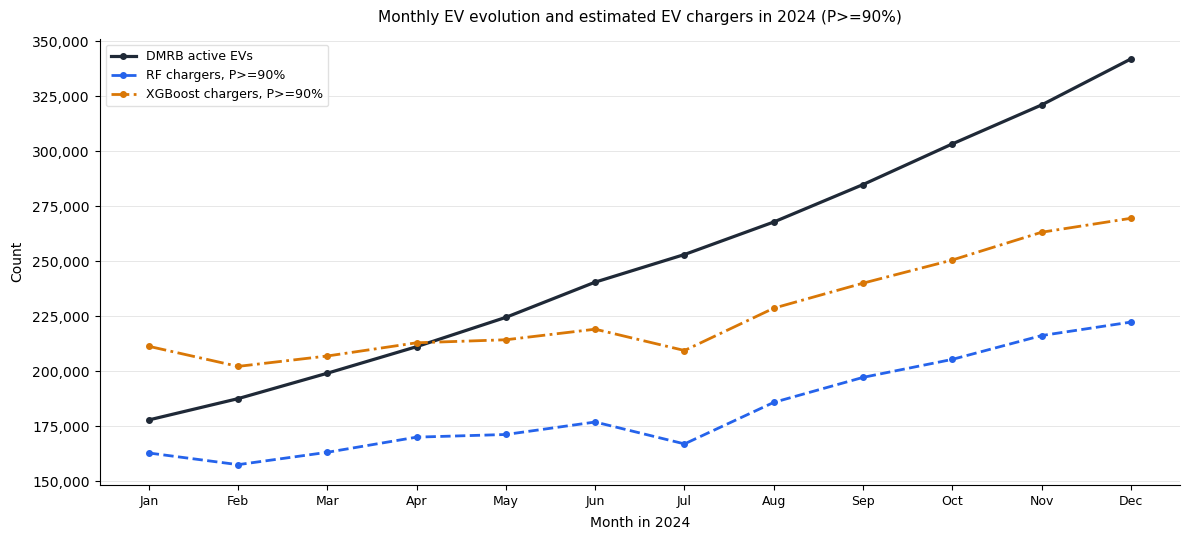

In [4]:
fig = plot_monthly_ev_and_chargers(
    df_ev=df_EVs,
    df_rf=df_rf,
    df_xgb=df_xgb,
    threshold=PROBABILITY_THRESHOLD,
    save_path=save_path_EVs / f"monthly_ev_and_chargers_p{int(PROBABILITY_THRESHOLD * 100)}.png",
    dpi=200,
)

plt.show()